Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters found: {'n_estimators': 250, 'max_depth': 15}
Train R²: 0.962, Test R²: 0.810
Q² Train: 0.794, Q² Test: 0.711
RMSE: 0.574, MAE: 0.436
Training Time: 301.08 sec


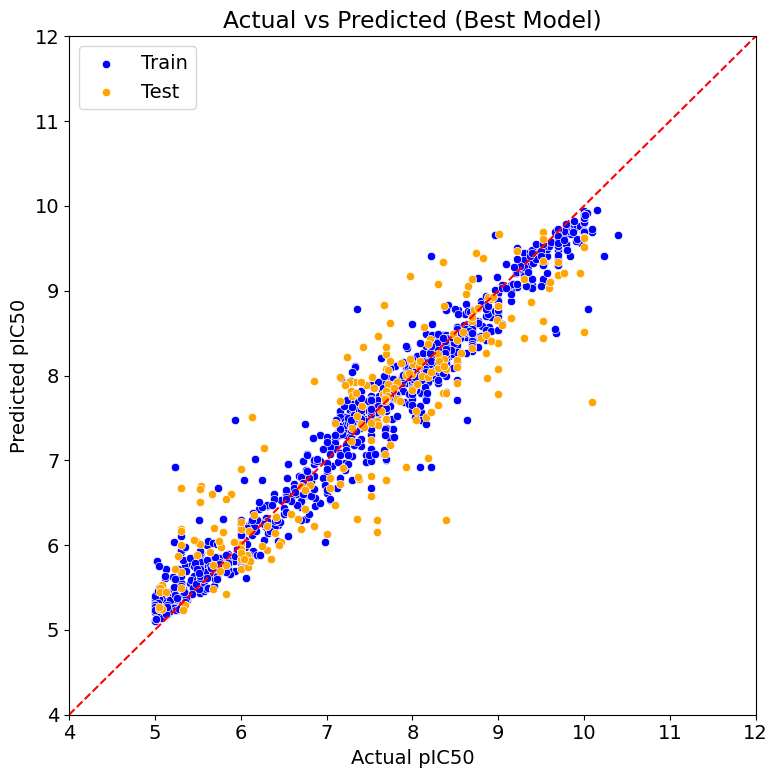

In [1]:
import pandas as pd
import numpy as np
import time
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# === Load and preprocess data ===
df = pd.read_csv('NaN_drop_MDM2.csv', low_memory=False)
ids = df['Smiles'] if 'Smiles' in df.columns else pd.Series([f'Mol_{i}' for i in range(len(df))])
target = df['pIC50']
features = df.drop(columns=['Smiles', 'pIC50'], errors='ignore')

# Convert all features to numeric and drop columns with NaNs
features = features.apply(pd.to_numeric, errors='coerce')
features = features.dropna(axis=1)

# Variance Threshold Filtering
selector = VarianceThreshold(threshold=0.01)
features_var = selector.fit_transform(features)
features = pd.DataFrame(features_var, columns=features.columns[selector.get_support()])

# Correlation Filtering
corr_matrix = features.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
features = features.drop(columns=to_drop)

# Feature Importance (Random Forest)
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(features, target)
importances = pd.Series(rf.feature_importances_, index=features.columns)
top_features = importances.sort_values(ascending=False).head(50).index
features = features[top_features]

# Save feature names used for training
with open('used_feature_names.txt', 'w') as f:
    for col in features.columns:
        f.write(f"{col}\n")
pd.DataFrame({'feature': features.columns}).to_csv('used_features.csv', index=False)

# Scale features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
features = pd.DataFrame(features_scaled, columns=features.columns)
joblib.dump(scaler, 'scaler.pkl')

# Split data
X_temp, X_val, y_temp, y_val, id_temp, id_val = train_test_split(features, target, ids, test_size=0.15, random_state=42)
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(X_temp, y_temp, id_temp, test_size=0.1765, random_state=42)

# Save sets with Smiles as the ID column
pd.concat([df.loc[id_train.index, 'Smiles'].reset_index(drop=True), X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1).to_csv('train_set.csv', index=False)
pd.concat([df.loc[id_test.index, 'Smiles'].reset_index(drop=True), X_test.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1).to_csv('test_set.csv', index=False)
pd.concat([df.loc[id_val.index, 'Smiles'].reset_index(drop=True), X_val.reset_index(drop=True), y_val.reset_index(drop=True)], axis=1).to_csv('validation_set.csv', index=False)

# RandomizedSearchCV for hyperparameter tuning
param_dist = {
    'n_estimators': [100, 150, 200, 250, 300],
    'max_depth': [None, 10, 15, 20, 25],
}

randomized_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# Train the best model
start_time = time.time()
randomized_search.fit(X_train, y_train)
best_model = randomized_search.best_estimator_
print(f"Best parameters found: {randomized_search.best_params_}")

# Predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Q² Train
kf = KFold(n_splits=8, shuffle=True, random_state=42)
q2_train_preds = np.zeros(len(X_train))
for train_idx, val_idx in kf.split(X_train):
    model_k = RandomForestRegressor(
        n_estimators=randomized_search.best_params_['n_estimators'],
        max_depth=randomized_search.best_params_['max_depth'],
        random_state=42, n_jobs=-1)
    model_k.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
    q2_train_preds[val_idx] = model_k.predict(X_train.iloc[val_idx])
q2_train = r2_score(y_train, q2_train_preds)

# Q² Test
q2_test_preds = np.zeros(len(X_test))
for train_idx, val_idx in kf.split(X_test):
    model_k = RandomForestRegressor(
        n_estimators=randomized_search.best_params_['n_estimators'],
        max_depth=randomized_search.best_params_['max_depth'],
        random_state=42, n_jobs=-1)
    model_k.fit(X_test.iloc[train_idx], y_test.iloc[train_idx])
    q2_test_preds[val_idx] = model_k.predict(X_test.iloc[val_idx])
q2_test = r2_score(y_test, q2_test_preds)

# Evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae = mean_absolute_error(y_test, y_test_pred)

result = {
    'train_r2': r2_score(y_train, y_train_pred),
    'test_r2': r2_score(y_test, y_test_pred),
    'q2_train': q2_train,
    'q2_test': q2_test,
    'rmse': rmse,
    'mae': mae,
    'train_time_sec': round(time.time() - start_time, 2)
}

# Print evaluation
print(f"Train R²: {result['train_r2']:.3f}, Test R²: {result['test_r2']:.3f}")
print(f"Q² Train: {result['q2_train']:.3f}, Q² Test: {result['q2_test']:.3f}")
print(f"RMSE: {result['rmse']:.3f}, MAE: {result['mae']:.3f}")
print(f"Training Time: {result['train_time_sec']} sec")

# Save model and performance
pd.DataFrame([result]).to_csv('model_performance.csv', index=False)
joblib.dump(best_model, 'final_rf_model.joblib')

# Actual vs Predicted Plot with fixed axis and size
plt.figure(figsize=(8, 8))
plt.rcParams.update({'font.size': 14})  # Optional: larger font

sns.scatterplot(x=y_train, y=y_train_pred, label='Train', color='blue')
sns.scatterplot(x=y_test, y=y_test_pred, label='Test', color='orange')

# Diagonal ideal prediction line from 0 to 12
plt.plot([4, 12], [4, 12], '--r')

# Set axes from 0 to 12
plt.xlim(4, 12)
plt.ylim(4, 12)

plt.xlabel('Actual pIC50')
plt.ylabel('Predicted pIC50')
plt.title('Actual vs Predicted (Best Model)')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted_best_model.png', dpi=300)
plt.show()

# === Save combined actual vs predicted with IDs and set assignment ===
train_df = pd.DataFrame({
    'Smiles': id_train.values,
    'Set': 'train',
    'Actual_pIC50': y_train.values,
    'Predicted_pIC50': y_train_pred
})

test_df = pd.DataFrame({
    'Smiles': id_test.values,
    'Set': 'test',
    'Actual_pIC50': y_test.values,
    'Predicted_pIC50': y_test_pred
})

val_df = pd.DataFrame({
    'Smiles': id_val.values,
    'Set': 'validation',
    'Actual_pIC50': y_val.values,
    'Predicted_pIC50': np.nan  # No prediction on validation set
})

final_combined = pd.concat([train_df, test_df, val_df], ignore_index=True)
final_combined.to_csv('actual_vs_predicted_with_sets.csv', index=False)

**Y-Randomization**

In [2]:
from sklearn.utils import shuffle
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import pandas as pd

# === 1. Randomize y_train ===
y_train_shuffled = shuffle(y_train, random_state=42)

# === 2. Train Random Forest ===
rf = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=42)
rf.fit(X_train, y_train_shuffled)

# === 3. Predict on test set ===
y_test_pred = rf.predict(X_test)

# === 4. Evaluate performance ===
r2 = r2_score(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f'R² (Randomized): {r2:.4f}')
print(f'RMSE (Randomized): {rmse:.4f}')

# === 5. Save results to CSV ===
results_df = pd.DataFrame({
    'R2_randomized': [r2],
    'RMSE_randomized': [rmse]
})
results_df.to_csv('y_randomization_single_result.csv', index=False)

R² (Randomized): -0.1468
RMSE (Randomized): 1.4094


**Code for Model Selection & Finalization:**

Final Model Evaluation:
Train R²: 0.961, Test R²: 0.810
RMSE: 0.574, MAE: 0.436
Training Time: 7.04 sec


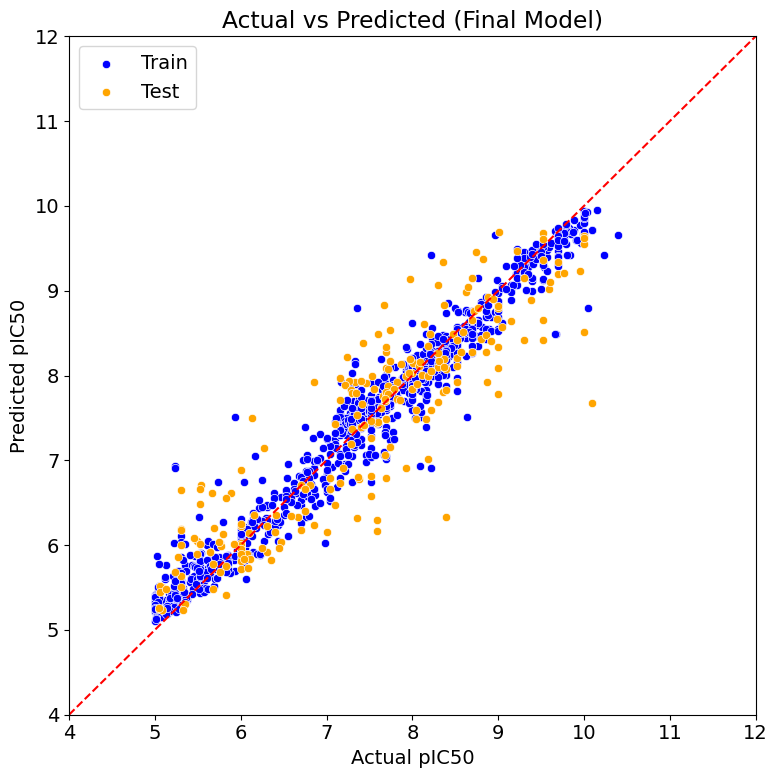

In [3]:
import pandas as pd
import numpy as np
import time
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# === Load pre-split training and test data ===
train_df = pd.read_csv('train_set.csv')
test_df = pd.read_csv('test_set.csv')

# Preserve Smiles for output
train_smiles = train_df['Smiles'] if 'Smiles' in train_df.columns else None
test_smiles = test_df['Smiles'] if 'Smiles' in test_df.columns else None

# Drop Smiles from modeling
X_train = train_df.drop(columns=['pIC50', 'Smiles'], errors='ignore')
y_train = train_df['pIC50']
X_test = test_df.drop(columns=['pIC50', 'Smiles'], errors='ignore')
y_test = test_df['pIC50']

# === Load previously optimized model hyperparameters ===
best_model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)

# === Train the final model ===
start_time = time.time()
best_model.fit(X_train, y_train)

# === Predict ===
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# === Evaluation Metrics ===
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae = mean_absolute_error(y_test, y_test_pred)

# === Save the final model ===
joblib.dump(best_model, 'final_rf_model.joblib')
joblib.dump(best_model, 'final_model.pkl')

# === Save performance metrics ===
result = {
    'train_r2': train_r2,
    'test_r2': test_r2,
    'rmse': rmse,
    'mae': mae,
    'train_time_sec': round(time.time() - start_time, 2)
}
results_df = pd.DataFrame([result])
results_df.to_csv('final_model_performance.csv', index=False)

# === Print performance ===
print("Final Model Evaluation:")
print(f"Train R²: {train_r2:.3f}, Test R²: {test_r2:.3f}")
print(f"RMSE: {rmse:.3f}, MAE: {mae:.3f}")
print(f"Training Time: {result['train_time_sec']} sec")

# === Save Actual vs Predicted with Smiles ===
train_results = pd.DataFrame({
    'Smiles': train_smiles,
    'Actual pIC50': y_train,
    'Predicted pIC50': y_train_pred,
    'Set': 'Train'
})
test_results = pd.DataFrame({
    'Smiles': test_smiles,
    'Actual pIC50': y_test,
    'Predicted pIC50': y_test_pred,
    'Set': 'Test'
})
combined_results = pd.concat([train_results, test_results], axis=0)
combined_results.to_csv('final_actual_vs_predicted.csv', index=False)

# === Plot Actual vs Predicted ===
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_train, y=y_train_pred, label='Train', color='blue')
sns.scatterplot(x=y_test, y=y_test_pred, label='Test', color='orange')
plt.plot([4, 12], [4, 12], '--r')  # Diagonal line with fixed axis
plt.xlim(4, 12)
plt.ylim(4, 12)
plt.xlabel('Actual pIC50')
plt.ylabel('Predicted pIC50')
plt.title("Actual vs Predicted (Final Model)")
plt.legend()
plt.tight_layout()
plt.savefig('final_actual_vs_predicted.png', dpi=300)
plt.show()

**Code for External Validation:**

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
540 fits failed out of a total of 1620.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
156 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.11/dist-packages/sklearn/uti

External Validation Results:
EXTERNAL_R2: 0.945
EXTERNAL_Q2: 0.740
EXTERNAL_RMSE: 0.318
EXTERNAL_MAE: 0.253
EVALUATION_TIME_SEC: 0.030


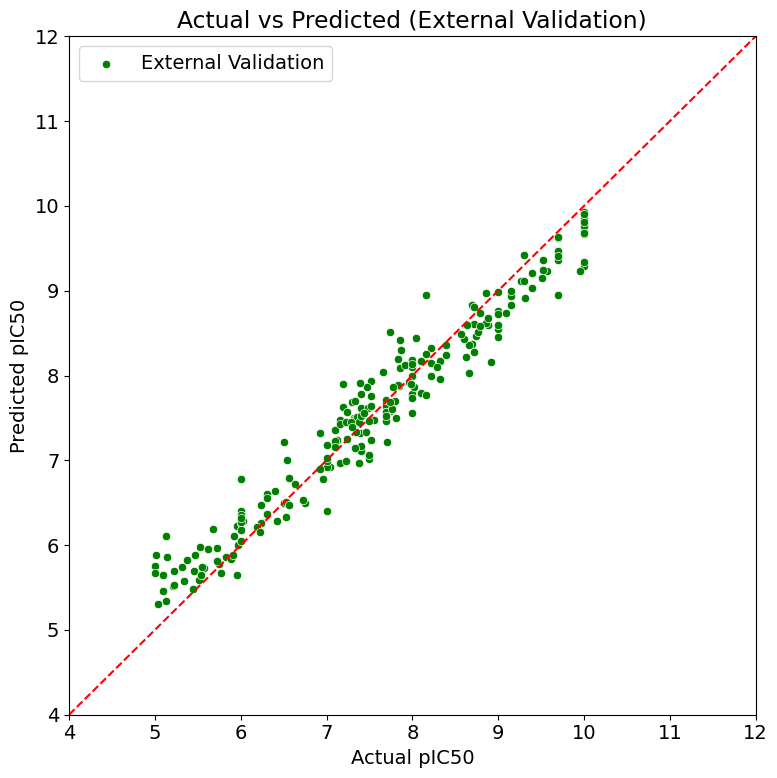

In [5]:
import pandas as pd
import numpy as np
import time
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold, cross_val_predict, GridSearchCV
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# === Load and preprocess external validation data ===
external_df = pd.read_csv('validation_set.csv', low_memory=False)  # External validation set
external_target = external_df['pIC50']  # Target variable
external_features = external_df.drop(columns=['Smiles', 'pIC50'], errors='ignore')  # Features

# Convert all features to numeric and drop columns with NaNs
external_features = external_features.apply(pd.to_numeric, errors='coerce')
external_features = external_features.dropna(axis=1)  # Remove columns with NaNs

# Load feature names used during training
with open('used_feature_names.txt', 'r') as f:
    top_features = [line.strip() for line in f.readlines()]

# Align external features to the exact training features
external_features = external_features[top_features]

# === Load scaler and scale external features ===
scaler = joblib.load('scaler.pkl')
external_features_scaled = scaler.transform(external_features)

# === Load trained model (RandomForest) ===
best_model = joblib.load('final_rf_model.joblib')

# === Hyperparameter tuning using GridSearchCV ===
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

# Initialize Random Forest model for tuning
rf = RandomForestRegressor(random_state=42)

# Perform grid search with cross-validation
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(external_features_scaled, external_target)

# Get the best model from GridSearchCV
best_rf_model = grid_search.best_estimator_

# === Predict on the External Validation Set ===
start_time = time.time()
external_predictions = best_rf_model.predict(external_features_scaled)
evaluation_time = round(time.time() - start_time, 2)

# === Evaluate Model Performance ===
external_r2 = r2_score(external_target, external_predictions)
external_rmse = np.sqrt(mean_squared_error(external_target, external_predictions))
external_mae = mean_absolute_error(external_target, external_predictions)

# === Q² (cross-validated R² using K-Fold on external set) ===
kf = KFold(n_splits=5, shuffle=True, random_state=42)
q2_cv_preds = cross_val_predict(best_rf_model, external_features_scaled, external_target, cv=kf)
external_q2 = r2_score(external_target, q2_cv_preds)

# === Print and Save Results ===
external_results = {
    'external_r2': external_r2,
    'external_q2': external_q2,
    'external_rmse': external_rmse,
    'external_mae': external_mae,
    'evaluation_time_sec': evaluation_time
}

print("External Validation Results:")
for key, val in external_results.items():
    print(f"{key.upper()}: {val:.3f}" if isinstance(val, float) else f"{key.upper()}: {val}")

# Save evaluation metrics
external_results_df = pd.DataFrame([external_results])
external_results_df.to_csv('external_validation_results.csv', index=False)

# Save predictions
results_df = external_df.copy()
results_df['Predicted_pIC50'] = external_predictions
results_df.to_csv('predicted_activity_all_external.csv', index=False)

# === Plot Actual vs Predicted (External Validation) ===
plt.figure(figsize=(8, 8))
sns.scatterplot(x=external_target, y=external_predictions, color='green', label='External Validation')

# Fixed axis range from 4 to 12, matching internal validation plots
plt.plot([4, 12], [4, 12], '--r')  # Diagonal ideal line
plt.xlim(4, 12)
plt.ylim(4, 12)

plt.xlabel('Actual pIC50')
plt.ylabel('Predicted pIC50')
plt.title("Actual vs Predicted (External Validation)")
plt.legend()
plt.tight_layout()
plt.savefig('external_validation_actual_vs_predicted.png', dpi=300)
plt.show()

**Code for Interpretation and Identifying Key Descriptors:**

Top 10 Important Features:
       Feature  Importance
0   naAromAtom    0.375966
2        nAcid    0.071467
3        SaasC    0.046214
6   SpMax1_Bhm    0.038410
1      nBondsD    0.034542
4   SpMax3_Bhm    0.030841
9      MLFER_S    0.024582
21     minwHBa    0.024172
10      maxHBa    0.020808
5     ETA_EtaP    0.020606


<ipython-input-6-03a7fdf0cc06>:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


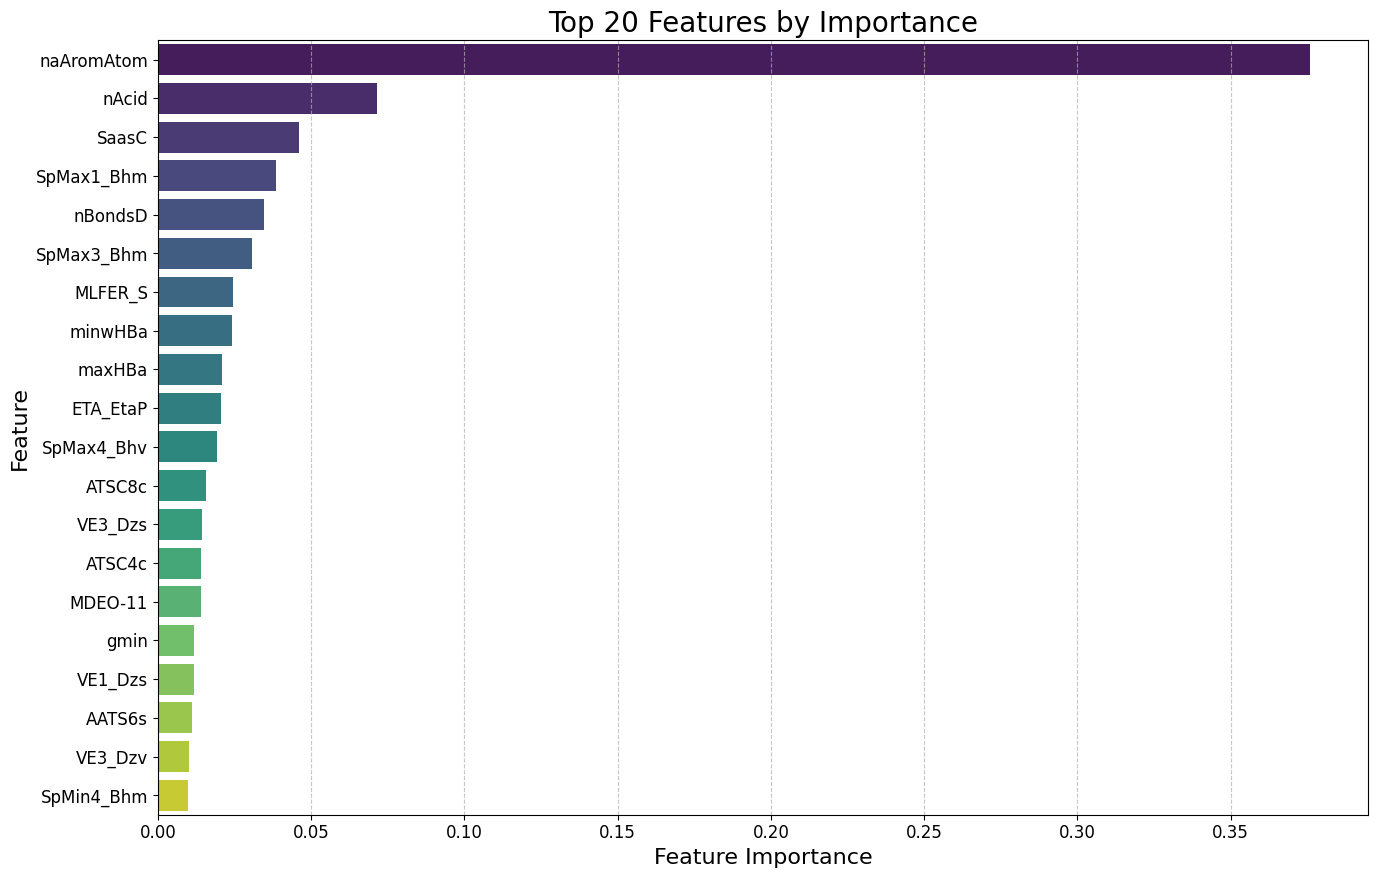

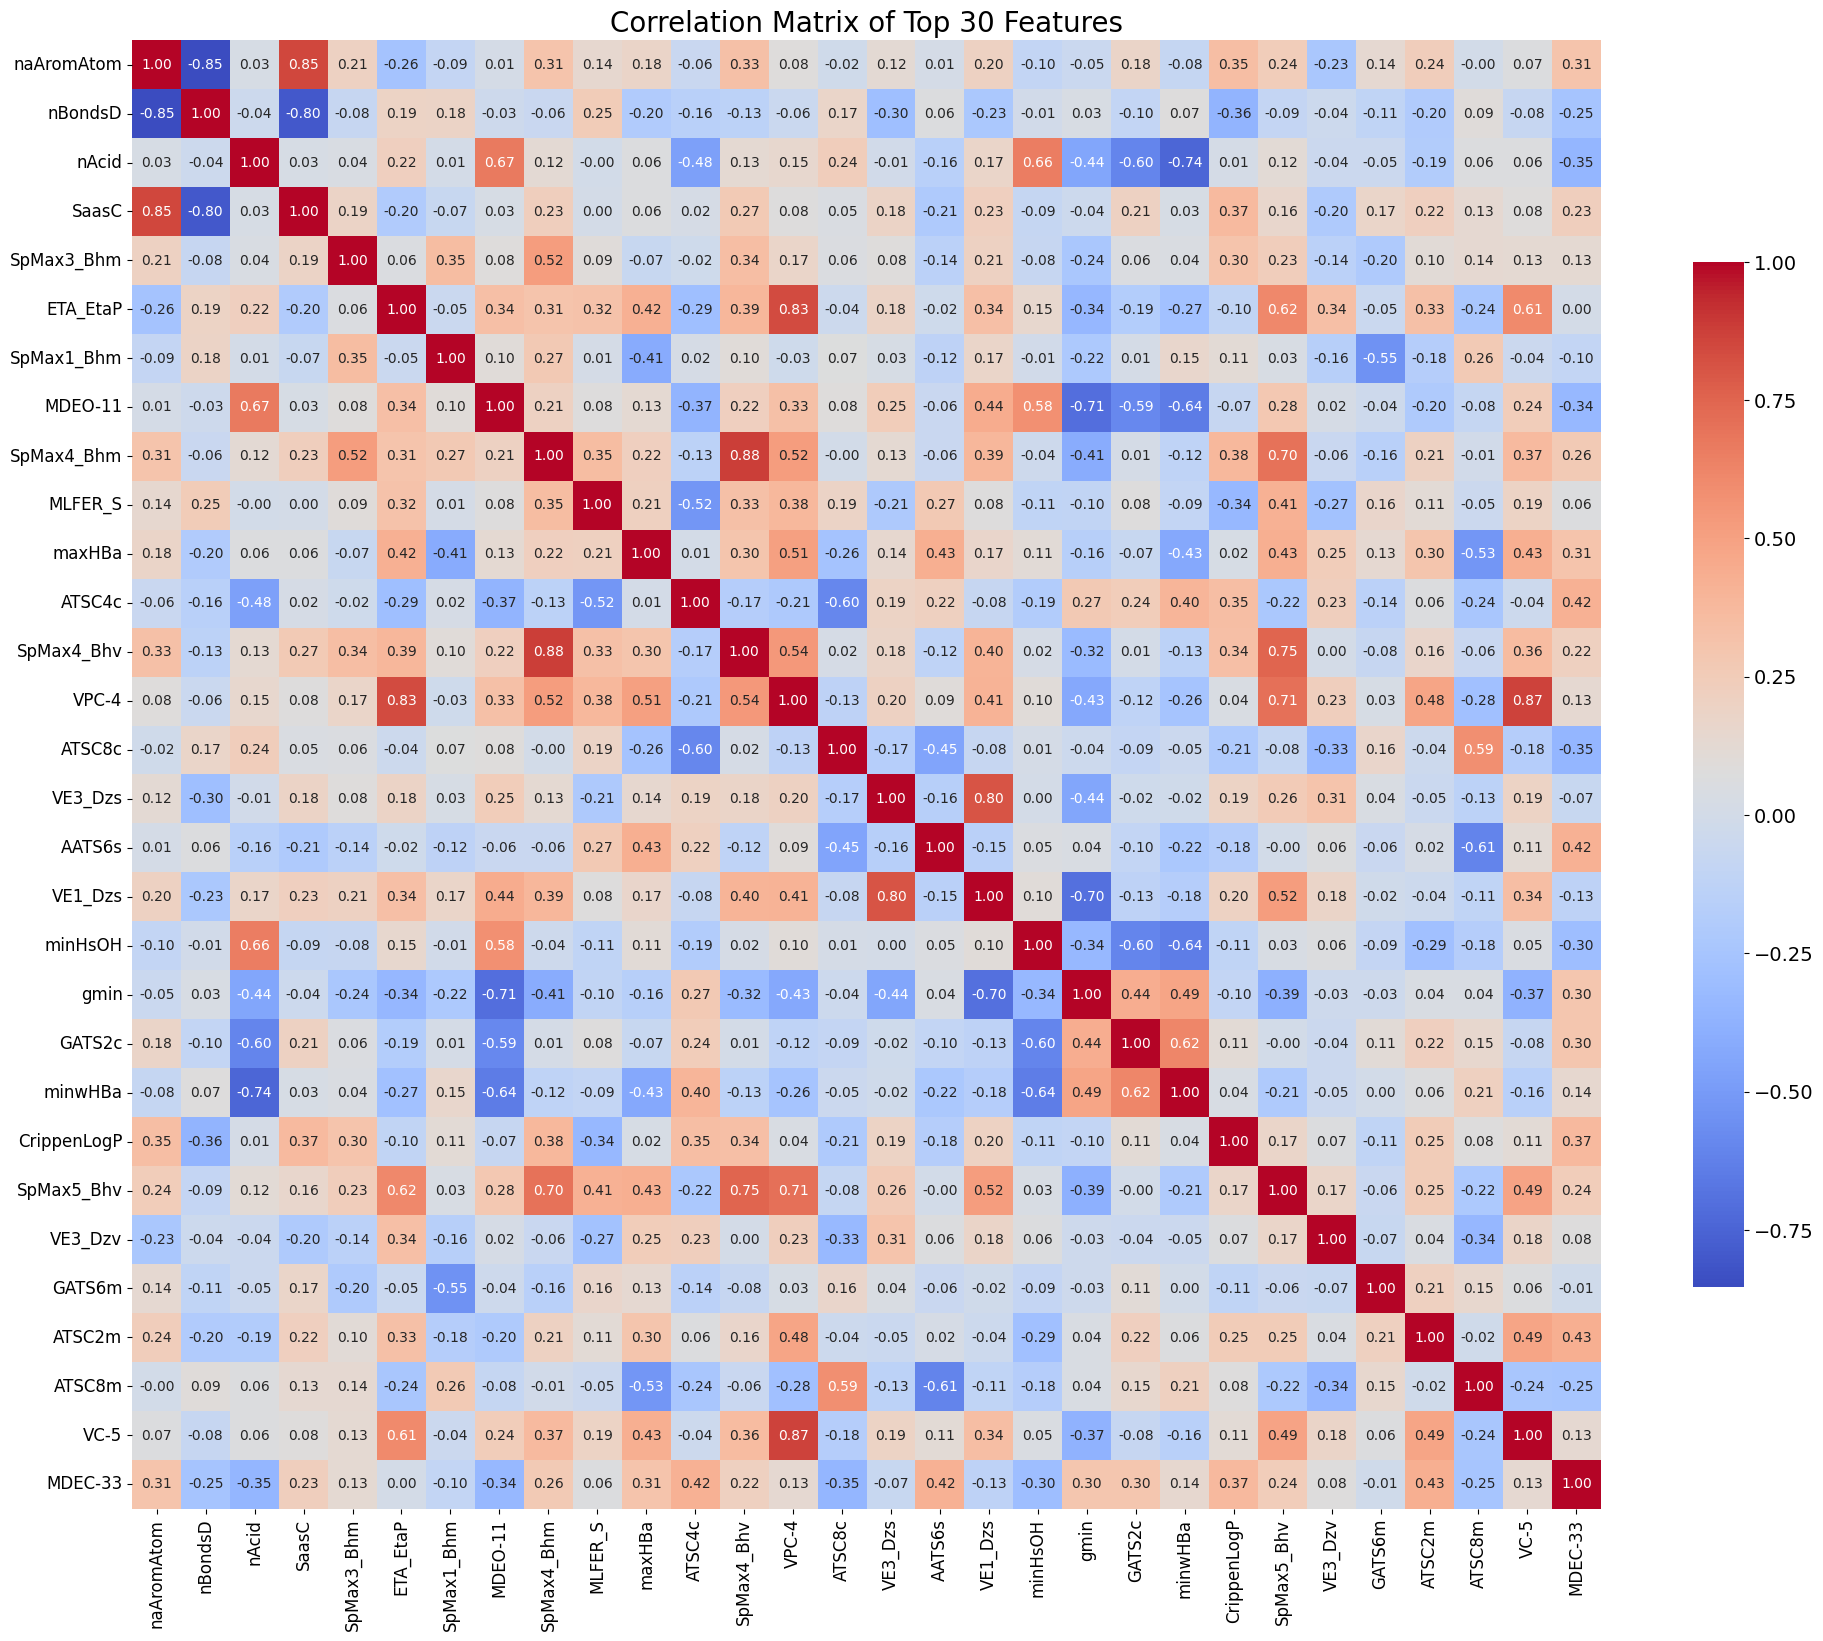

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Load final trained model and scaler
final_model = joblib.load('final_model.pkl')
scaler = joblib.load('scaler.pkl')

# Load dataset
df = pd.read_csv('NaN_drop_MDM2.csv', low_memory=False)

# Drop non-feature columns
features = df.drop(columns=['Name', 'pIC50'], errors='ignore')

# Load the exact features used during training
with open('used_feature_names.txt', 'r') as f:
    used_features = [line.strip() for line in f.readlines()]

# Ensure only those features are used, in the correct order
features = features[used_features]

# Scale features
features_scaled = scaler.transform(features)

# Check if model supports feature importances
if not hasattr(final_model, 'feature_importances_'):
    raise AttributeError("The loaded model does not support feature importances.")

# Get and sort feature importances
importances = final_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': used_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Print top 10 features
print("Top 10 Important Features:")
print(importance_df.head(10))

# Plot top 20 feature importances (presentation format)
plt.figure(figsize=(14, 9))  # Larger figure for presentations
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df.head(20),
    palette='viridis'
)

plt.title('Top 20 Features by Importance', fontsize=20)
plt.xlabel('Feature Importance', fontsize=16)
plt.ylabel('Feature', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('feature_importance_plot_presentation.png', dpi=600)
plt.show()

# Save importances
importance_df.to_csv('feature_importance.csv', index=False)

# Select top 30 features used in the final model
top30_features = features.columns[:30]
corr_matrix_top30 = features[top30_features].corr()

# Plot heatmap for presentation
plt.figure(figsize=(20, 18))  # Larger figure for presentations
sns.heatmap(
    corr_matrix_top30,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    square=True,
    cbar_kws={"shrink": 0.6},
    annot_kws={"size": 10}  # Bigger annotation font
)

plt.xticks(rotation=90, fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.title('Correlation Matrix of Top 30 Features', fontsize=20)
plt.tight_layout()
plt.savefig('correlation_matrix_top30_presentation.png', dpi=600)  # High-res
plt.show()

Applicability Domain Code (Distance-Based for Random Forest)

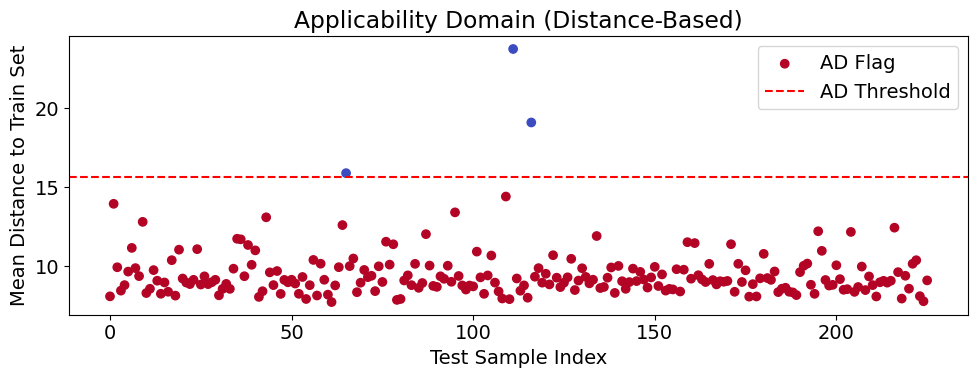

In [7]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import euclidean_distances
import matplotlib.pyplot as plt

# === Compute Euclidean distances of test samples to training set ===
# Note: Use scaled features for AD calculation (you already scaled them)
distances = euclidean_distances(X_test, X_train)
mean_distances = distances.mean(axis=1)

# === Determine threshold ===
# Use mean + 3*std of mean distances in the training set as the threshold
train_distances = euclidean_distances(X_train, X_train)
mean_train_distances = train_distances.mean(axis=1)
ad_threshold = mean_train_distances.mean() + 3 * mean_train_distances.std()

# === Flagging samples outside the AD ===
ad_flag = mean_distances <= ad_threshold  # True = inside AD, False = outside

# === Add to result dataframe ===
test_ad_df = pd.DataFrame({
    'Smiles': id_test.values,
    'Actual_pIC50': y_test.values,
    'Predicted_pIC50': y_test_pred,
    'AD_Inside': ad_flag,
    'Mean_Distance': mean_distances
})

# Save to CSV
test_ad_df.to_csv('test_set_with_ad_flag.csv', index=False)

# === Optional: Visualize AD distances ===
plt.figure(figsize=(10, 4))
plt.scatter(range(len(mean_distances)), mean_distances, c=ad_flag, cmap='coolwarm', label='AD Flag')
plt.axhline(y=ad_threshold, color='r', linestyle='--', label='AD Threshold')
plt.xlabel('Test Sample Index')
plt.ylabel('Mean Distance to Train Set')
plt.title('Applicability Domain (Distance-Based)')
plt.legend()
plt.tight_layout()
plt.savefig('applicability_domain_plot.png', dpi=300)
plt.show()